# Nemotron activation-distribution analysis

This notebook analyzes semantic activation categories saved by `activation_distribution.py`: token embeddings; FFN input, pre-activation, hidden, and output; attention input, Q/K/V, context, and output; Mamba input, projected, hidden, and output; final hidden states; and logits. Distribution parameters are fit by maximum likelihood using each candidate's probability integrated over histogram bins, with fit plotting provided by `histogram.py`. Exact-zero activations are modeled as a point mass; the remaining values use continuous bulk and tail distributions.

Generate or refresh the artifact by running `activation_distribution.py` before this notebook. Artifact format 3 is required because it records the exact-zero count for every activation category.

In [1]:
from pathlib import Path
import sys
import torch
from IPython.display import Markdown, display
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "llm_analysis" / "activation_distribution.py").exists():
            return candidate / "llm_analysis"
    raise FileNotFoundError("Could not locate the llm_analysis project root")
PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from histogram import (
    DEFAULT_BULK_MASS,
    fit_histogram_distributions,
    plot_histogram_fits,
)
RESULTS_PATH = PROJECT_ROOT / "activation_distribution_results.pt"
RESULTS_PATH


PosixPath('/home/bubbles/Documents/lossless_compression/llm_analysis/activation_distribution_results.pt')

In [2]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"{RESULTS_PATH} does not exist. Run activation_distribution.py first."
    )

results = torch.load(RESULTS_PATH, map_location="cpu", weights_only=True)
if results.get("format_version") != 3:
    raise ValueError(
        "Artifact format 3 is required for exact-zero fitting. "
        "Run activation_distribution.py to regenerate the results."
    )
histograms = results["histograms"]
zero_counts = results["zero_counts"]
edges = results["edges"]
extrema = results["extrema"]
category_specs = results["categories"]

metadata = {
    key: results[key]
    for key in (
        "model_name",
        "num_batches",
        "sequence_length",
        "sequences_per_batch",
        "bin_width",
        "limit",
    )
}
metadata

{'model_name': 'nvidia/Nemotron-H-8B-Base-8K',
 'num_batches': 4,
 'sequence_length': 1024,
 'sequences_per_batch': 1,
 'bin_width': 0.05,
 'limit': 150.0}

In [3]:
if (
    set(histograms) != set(extrema)
    or set(histograms) != set(category_specs)
    or set(histograms) != set(zero_counts)
):
    raise ValueError("Histogram, zero-count, extrema, and category labels do not match")
if any(counts.numel() != edges.numel() + 1 for counts in histograms.values()):
    raise ValueError("Histogram counts are incompatible with the saved bin edges")
if any(zero_counts[label] > counts.sum() for label, counts in histograms.items()):
    raise ValueError("An exact-zero count exceeds its histogram total")

summary_rows = []
for label, counts in histograms.items():
    minimum, maximum = extrema[label]
    spec = category_specs[label]
    module_path = spec["module_path"] or "<module>"
    capture_point = f'{spec["parent_type"]}.{module_path} {spec["capture"]}'
    total = int(counts.sum())
    overflow = int(counts[0] + counts[-1])
    zero_fraction = int(zero_counts[label]) / total
    summary_rows.append(
        (
            label,
            capture_point,
            f"{total:,}",
            f"{minimum.item():.6g}",
            f"{maximum.item():.6g}",
            f"{zero_fraction:.3%}",
            f"{overflow / total:.3%}",
        )
    )

def show_table(headers, rows):
    header = "| " + " | ".join(headers) + " |"
    divider = "| " + " | ".join("---" for _ in headers) + " |"
    body = ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown(chr(10).join((header, divider, *body))))

show_table(
    (
        "Activation category",
        "Capture point",
        "Observations",
        "Minimum",
        "Maximum",
        "Exact zeros",
        "Outside fit range",
    ),
    summary_rows,
)

| Activation category | Capture point | Observations | Minimum | Maximum | Exact zeros | Outside fit range |
| --- | --- | --- | --- | --- | --- | --- |
| Token embeddings | NemotronHForCausalLM.model.embeddings output | 16,777,216 | -0.196289 | 0.167969 | 0.000% | 0.000% |
| FFN input | NemotronHMLP.<module> input | 402,653,184 | -66.5 | 161 | 0.063% | 0.000% |
| FFN pre-activation | NemotronHMLP.up_proj output | 2,113,929,216 | -36.75 | 104.5 | 0.000% | 0.000% |
| FFN hidden | NemotronHMLP.down_proj input | 2,113,929,216 | 0 | 10944 | 93.059% | 0.000% |
| FFN output | NemotronHMLP.<module> output | 402,653,184 | -2032 | 1488 | 0.000% | 0.001% |
| Attention input | NemotronHAttention.<module> input | 67,108,864 | -55 | 110 | 0.064% | 0.000% |
| Attention query | NemotronHAttention.q_proj output | 67,108,864 | -16.5 | 14.6875 | 0.000% | 0.000% |
| Attention key | NemotronHAttention.k_proj output | 16,777,216 | -41.25 | 29.625 | 0.000% | 0.000% |
| Attention value | NemotronHAttention.v_proj output | 16,777,216 | -19.625 | 29.5 | 0.000% | 0.000% |
| Attention context | NemotronHAttention.o_proj input | 67,108,864 | -16.625 | 20.25 | 0.000% | 0.000% |
| Attention output | NemotronHAttention.<module> output | 67,108,864 | -103.5 | 88 | 0.000% | 0.000% |
| Mamba input | NemotronHMamba2Mixer.<module> input | 402,653,184 | -49 | 84.5 | 0.066% | 0.000% |
| Mamba projected | NemotronHMamba2Mixer.in_proj output | 1,824,522,240 | -65 | 59.75 | 0.000% | 0.000% |
| Mamba hidden | NemotronHMamba2Mixer.out_proj input | 805,306,368 | -380 | 636 | 0.000% | 0.000% |
| Mamba output | NemotronHMamba2Mixer.<module> output | 402,653,184 | -332 | 888 | 0.000% | 0.001% |
| Final hidden | NemotronHForCausalLM.model.norm_f output | 16,777,216 | -233 | 262 | 0.050% | 0.008% |
| Logits | NemotronHForCausalLM.lm_head output | 536,870,912 | -123.5 | 368 | 0.000% | 0.000% |

In [4]:
# Exact-zero activations form a point mass; the nonzero values receive the continuous fit.
# The primary tail fit is vertically anchored to the primary bulk fit at their shared boundary.
# Adjust the central-mass/tail split or show every candidate fit as needed.
bulk_mass = DEFAULT_BULK_MASS
show_all_candidates = False
fits = fit_histogram_distributions(
    histograms,
    edges,
    zero_counts=zero_counts,
    bulk_mass=bulk_mass,
)

fit_rows = []
for label, regions in fits.items():
    for region in ("bulk", "tail"):
        candidates = regions.get(region, [])
        if not candidates:
            fit_rows.append(
                (label, region, "-", "not fitted", "-", "-", "-", "<3 populated bins")
            )
            continue
        for rank, fit in enumerate(candidates, start=1):
            if rank > 1 and not show_all_candidates:
                continue
            fit_rows.append(
                (
                    label,
                    region,
                    rank,
                    f"zero-inflated {fit.family}"
                    if fit.has_material_zero_atom
                    else fit.family,
                    f"{fit.log_likelihood:.4g}",
                    f"{fit.log_rmse:.4f}",
                    f"{fit.r_squared:.4f}",
                    fit.parameters,
                )
            )

show_table(
    (
        "Activation category",
        "Region",
        "Rank",
        "Family",
        "Log-likelihood",
        "log-RMSE",
        "R²",
        "Parameters",
    ),
    fit_rows,
)

| Activation category | Region | Rank | Family | Log-likelihood | log-RMSE | R² | Parameters |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Token embeddings | bulk | 1 | gaussian | -1.167e+07 | 0.4500 | 0.9656 | mu=4.936e-07, sigma=0.01474 |
| Token embeddings | tail | 1 | gaussian | -6990 | 4.4850 | -6.3889 | mu=4.936e-07, sigma=0.05677 |
| FFN input | bulk | 1 | zero-inflated polynomial | -1.465e+09 | 0.0577 | 0.9986 | mu=0.002101, scale=0.4933, exponent=2.383, zero_mass=0.063% |
| FFN input | tail | 1 | zero-inflated polynomial | -9.201e+07 | 0.3342 | 0.9971 | mu=0.002101, scale=0.00789, exponent=3.941, zero_mass=0.063% |
| FFN pre-activation | bulk | 1 | polynomial | -8.955e+09 | 0.6398 | 0.9124 | mu=-0.676, scale=1.555, exponent=3.07 |
| FFN pre-activation | tail | 1 | exponential | -4.872e+08 | 1.2130 | 0.9814 | mu=-0.676, scale=0.9782 |
| FFN hidden | bulk | 1 | zero-inflated polynomial | -2.92e+08 | 1.3392 | 0.8686 | mu=0.04683, scale=5.14e-05, exponent=1.031, zero_mass=93.059% |
| FFN hidden | tail | 1 | zero-inflated polynomial | -4.359e+07 | 0.6524 | 0.9367 | mu=0.04683, scale=2.123, exponent=2.817, zero_mass=93.059% |
| FFN output | bulk | 1 | polynomial | -1.288e+09 | 0.2091 | 0.9935 | mu=0.0003894, scale=0.006704, exponent=1.031 |
| FFN output | tail | 1 | polynomial | -9.852e+07 | 0.3539 | 0.9962 | mu=0.0003894, scale=0.6097, exponent=4.076 |
| Attention input | bulk | 1 | zero-inflated exponential | -2.468e+08 | 0.0708 | 0.9953 | mu=0.00459, scale=0.5314, zero_mass=0.064% |
| Attention input | tail | 1 | zero-inflated polynomial | -1.611e+07 | 0.3657 | 0.9949 | mu=0.00459, scale=0.0003737, exponent=3.224, zero_mass=0.064% |
| Attention query | bulk | 1 | gaussian | -2.733e+08 | 0.0828 | 0.9907 | mu=-0.0001311, sigma=0.9235 |
| Attention query | tail | 1 | polynomial | -1.612e+07 | 0.3995 | 0.9893 | mu=-0.0001311, scale=9.63, exponent=11.95 |
| Attention key | bulk | 1 | exponential | -8.28e+07 | 0.1434 | 0.9786 | mu=0.017, scale=2.046 |
| Attention key | tail | 1 | polynomial | -4.888e+06 | 0.4143 | 0.9557 | mu=0.017, scale=4.791, exponent=5.119 |
| Attention value | bulk | 1 | polynomial | -6.523e+07 | 0.0879 | 0.9975 | mu=0.00166, scale=0.6142, exponent=2.415 |
| Attention value | tail | 1 | polynomial | -4.221e+06 | 0.2336 | 0.9965 | mu=0.00166, scale=156.5, exponent=108.8 |
| Attention context | bulk | 1 | polynomial | -1.597e+08 | 0.1522 | 0.9944 | mu=0.001209, scale=0.02307, exponent=1.378 |
| Attention context | tail | 1 | polynomial | -1.297e+07 | 0.3701 | 0.9970 | mu=0.001209, scale=1.317, exponent=6.173 |
| Attention output | bulk | 1 | polynomial | -1.62e+08 | 0.1612 | 0.9937 | mu=0.0001174, scale=0.01703, exponent=1.272 |
| Attention output | tail | 1 | polynomial | -1.268e+07 | 0.4515 | 0.9970 | mu=0.0001174, scale=0.7593, exponent=5.173 |
| Mamba input | bulk | 1 | zero-inflated gaussian | -1.463e+09 | 0.1024 | 0.9854 | mu=0.004022, sigma=0.5862, zero_mass=0.066% |
| Mamba input | tail | 1 | zero-inflated polynomial | -8.822e+07 | 0.5577 | 0.9925 | mu=0.004022, scale=0.00171, exponent=3.742, zero_mass=0.066% |
| Mamba projected | bulk | 1 | exponential | -7.353e+09 | 0.0891 | 0.9942 | mu=-0.06355, scale=0.7327 |
| Mamba projected | tail | 1 | polynomial | -4.494e+08 | 0.4353 | 0.9958 | mu=-0.06355, scale=13.9, exponent=14.42 |
| Mamba hidden | bulk | 1 | polynomial | -1.745e+09 | 0.3401 | 0.9866 | mu=0.000635, scale=0.008008, exponent=1.33 |
| Mamba hidden | tail | 1 | polynomial | -2.052e+08 | 0.3790 | 0.9949 | mu=0.000635, scale=0.2657, exponent=2.488 |
| Mamba output | bulk | 1 | polynomial | -1.203e+09 | 0.2229 | 0.9944 | mu=0.0001053, scale=0.008386, exponent=1.14 |
| Mamba output | tail | 1 | polynomial | -1.1e+08 | 0.4753 | 0.9892 | mu=0.0001053, scale=2.248, exponent=3.791 |
| Final hidden | bulk | 1 | zero-inflated gaussian | -8.745e+07 | 0.1597 | 0.9502 | mu=-0.01982, sigma=3.21, zero_mass=0.050% |
| Final hidden | tail | 1 | zero-inflated polynomial | -5.26e+06 | 0.7313 | 0.9226 | mu=-0.01982, scale=0.0009312, exponent=3.202, zero_mass=0.050% |
| Logits | bulk | 1 | gaussian | -2.724e+09 | 0.1887 | 0.9239 | mu=-1.44, sigma=2.807 |
| Logits | tail | 1 | polynomial | -1.597e+08 | 1.2186 | 0.9380 | mu=-1.44, scale=0.001443, exponent=3.491 |

## FFN

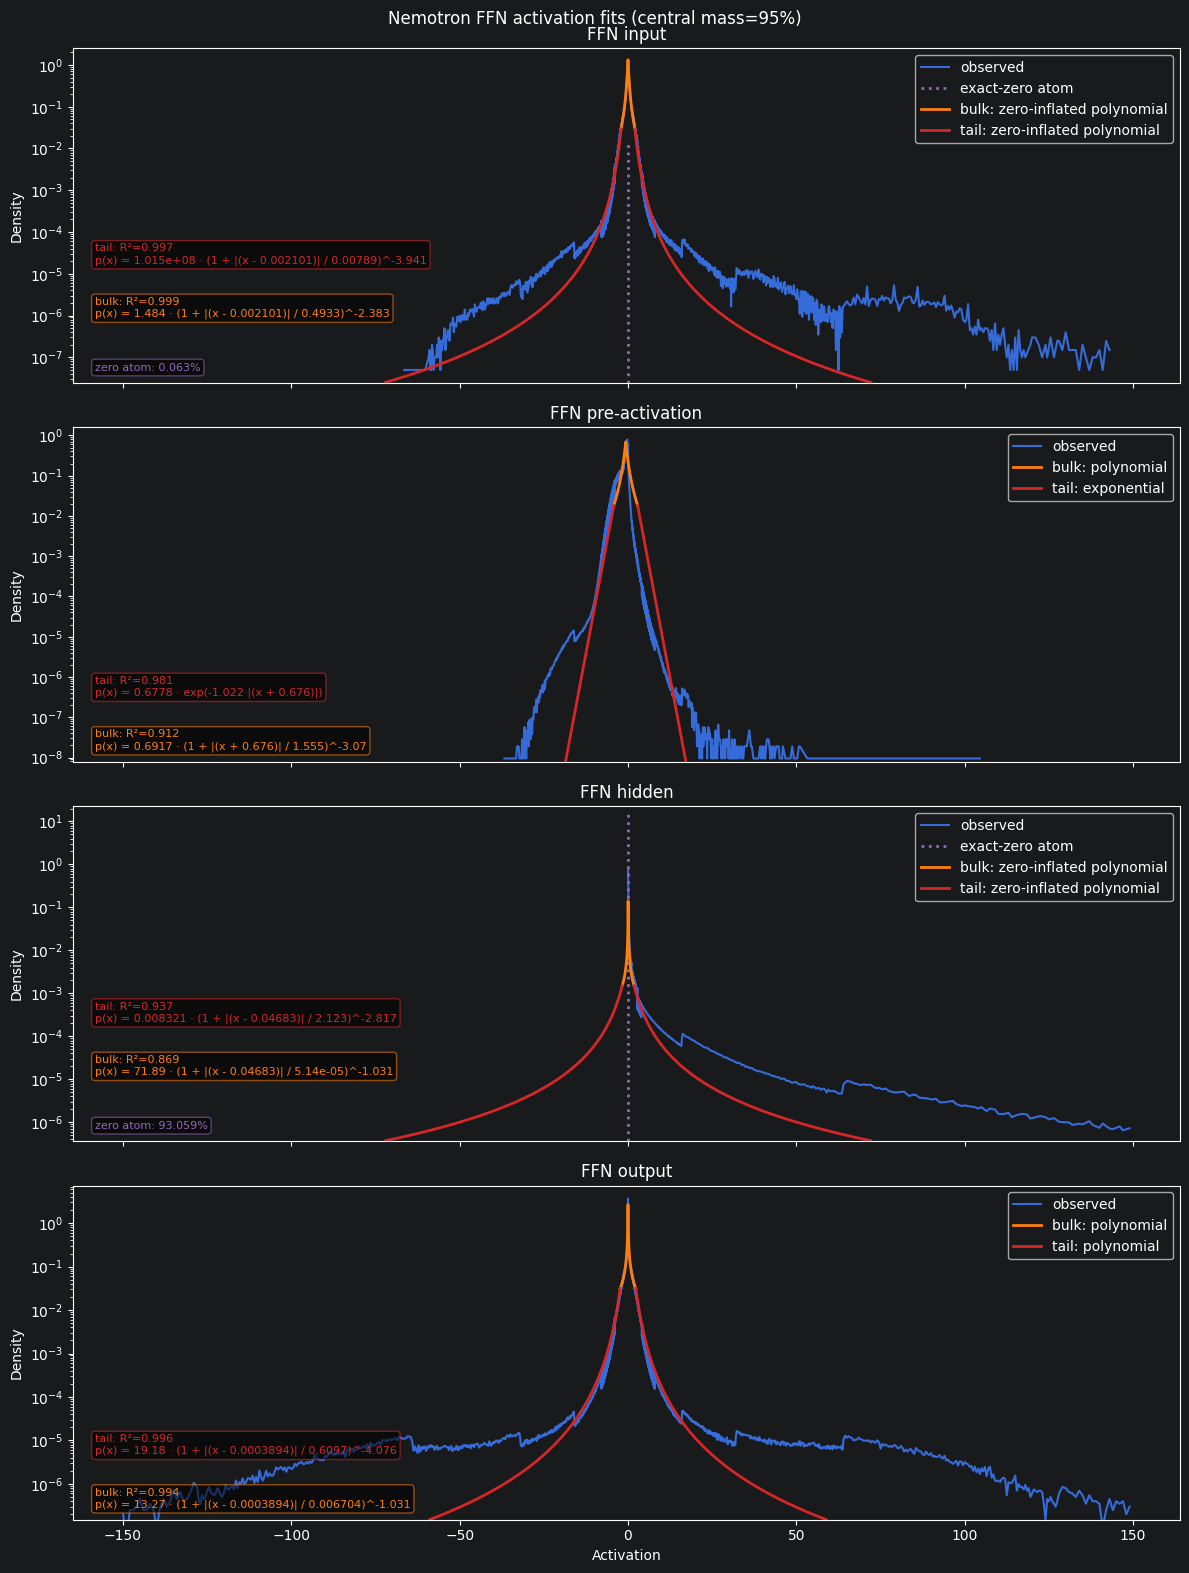

## Attention

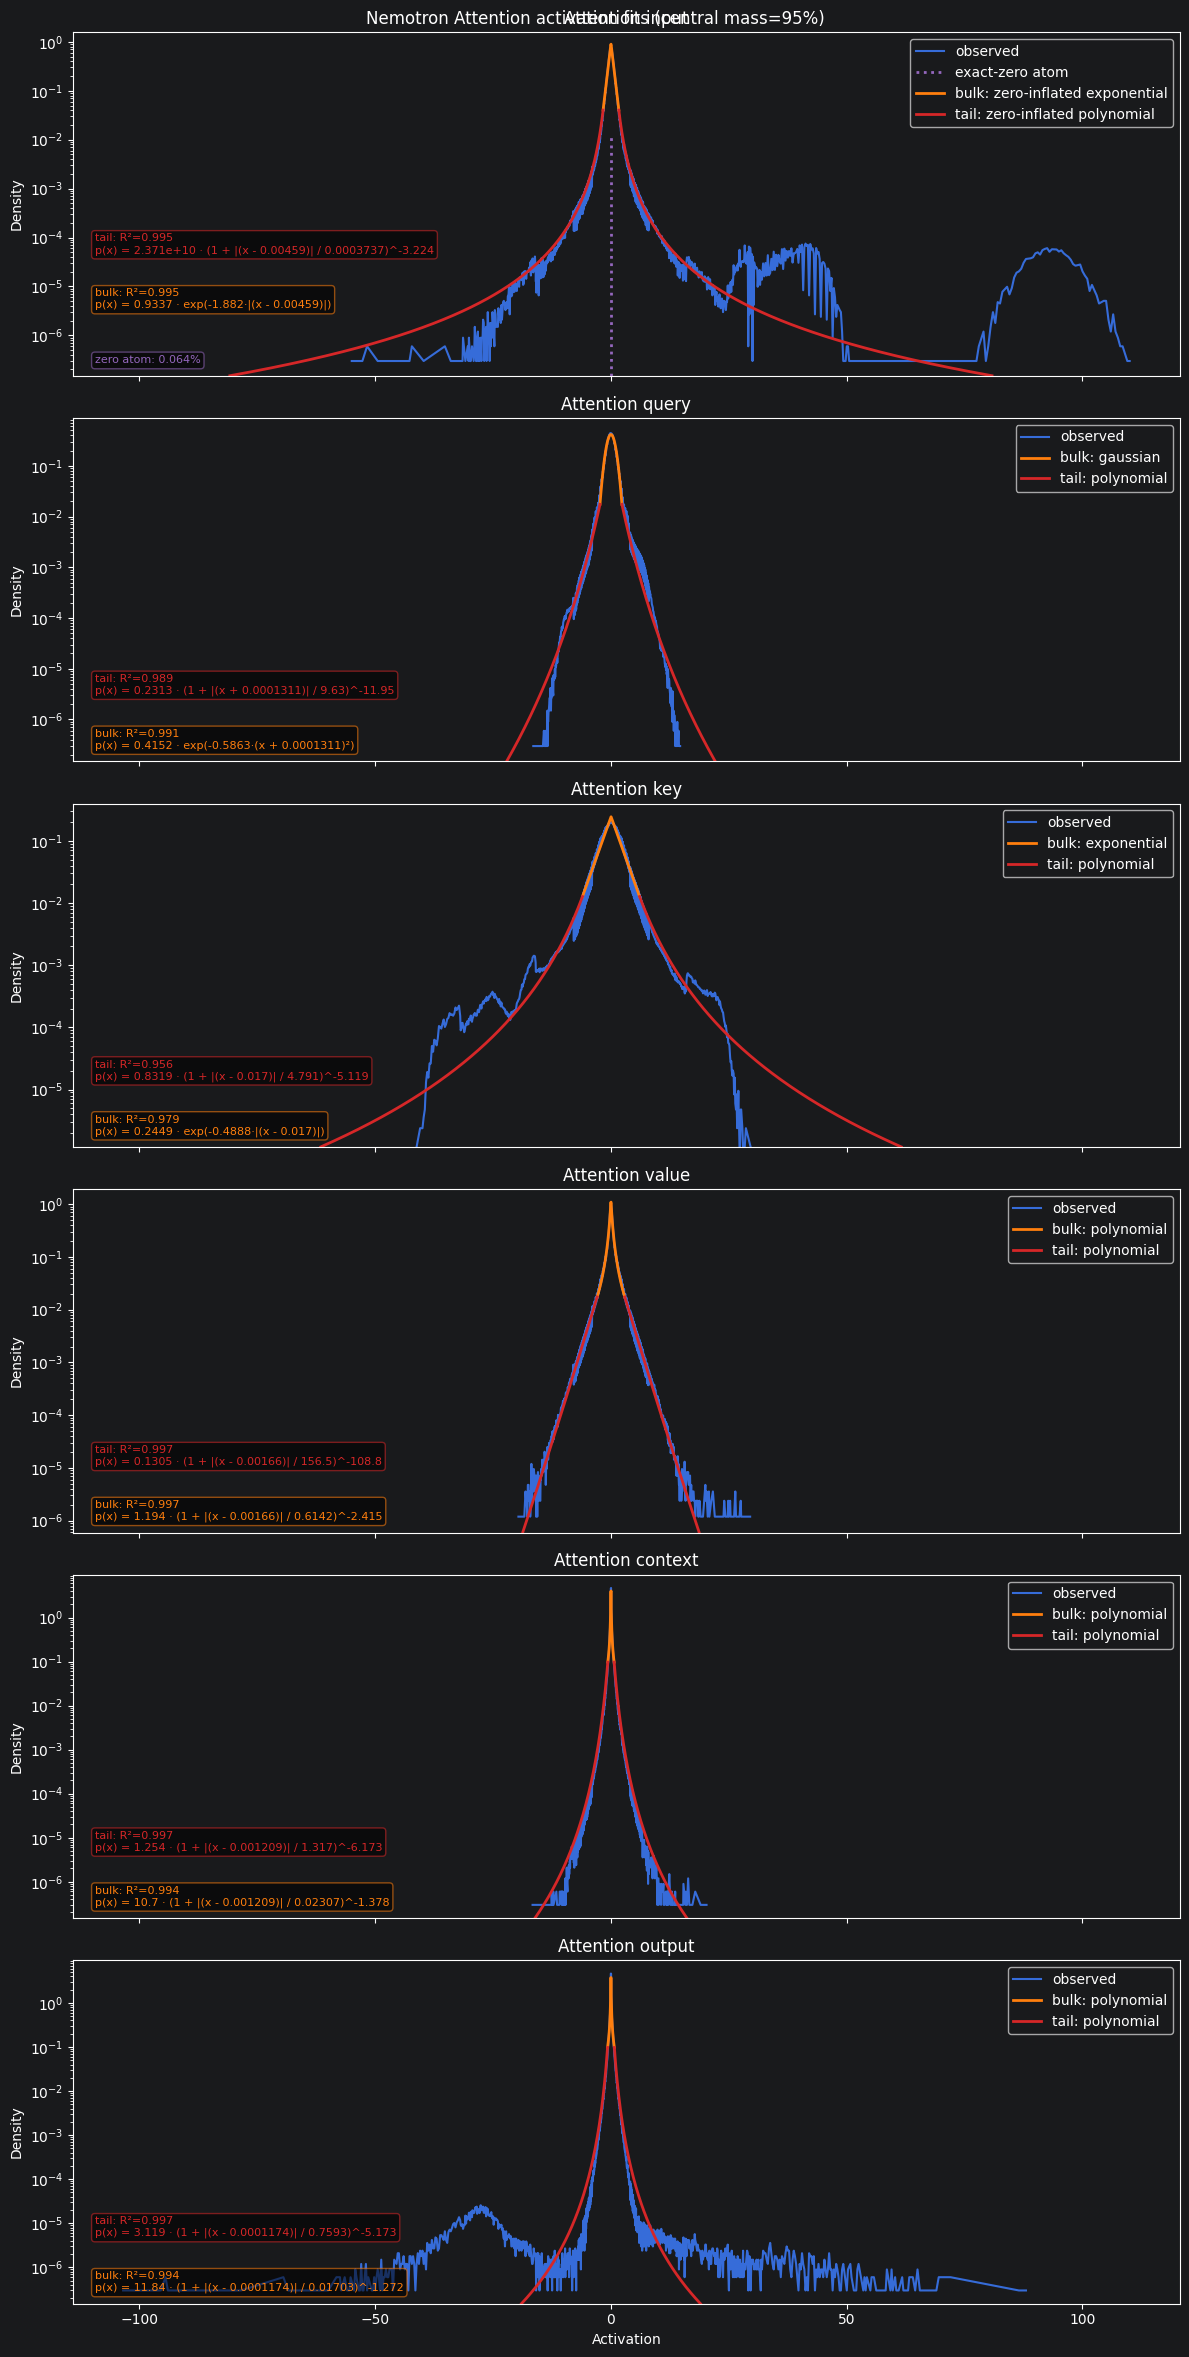

## Mamba

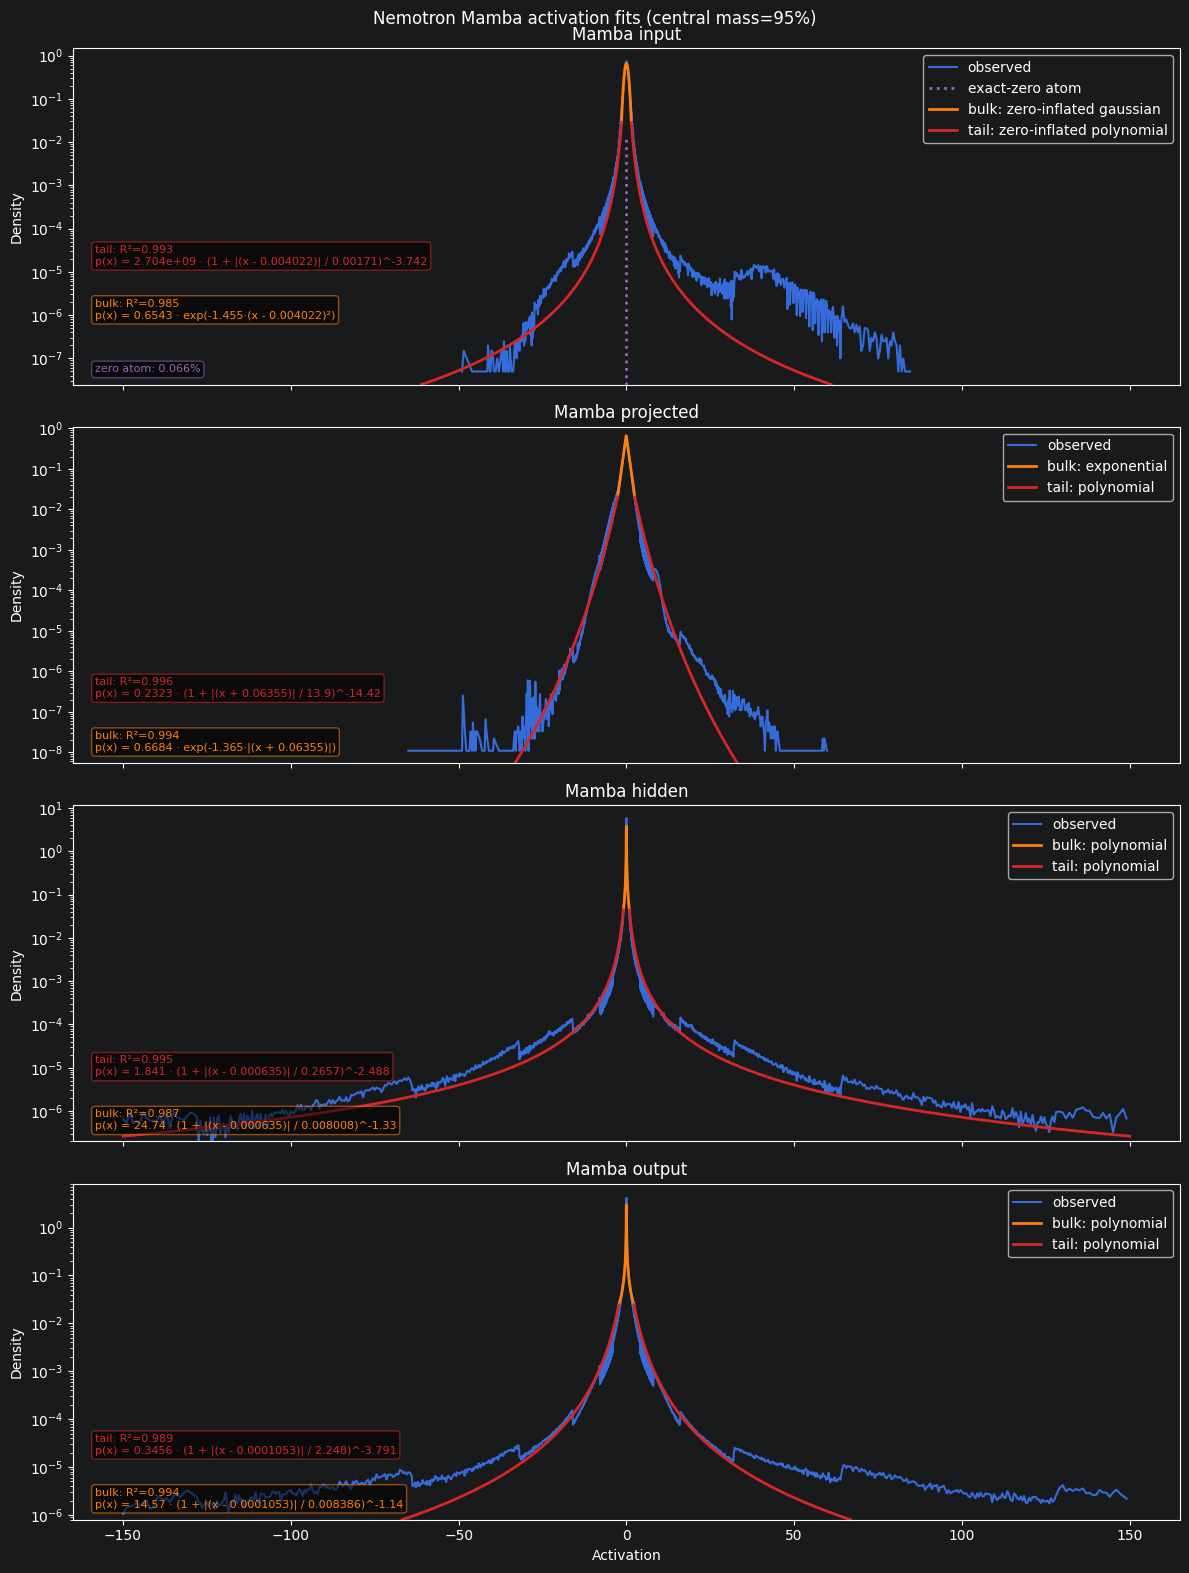

## Other

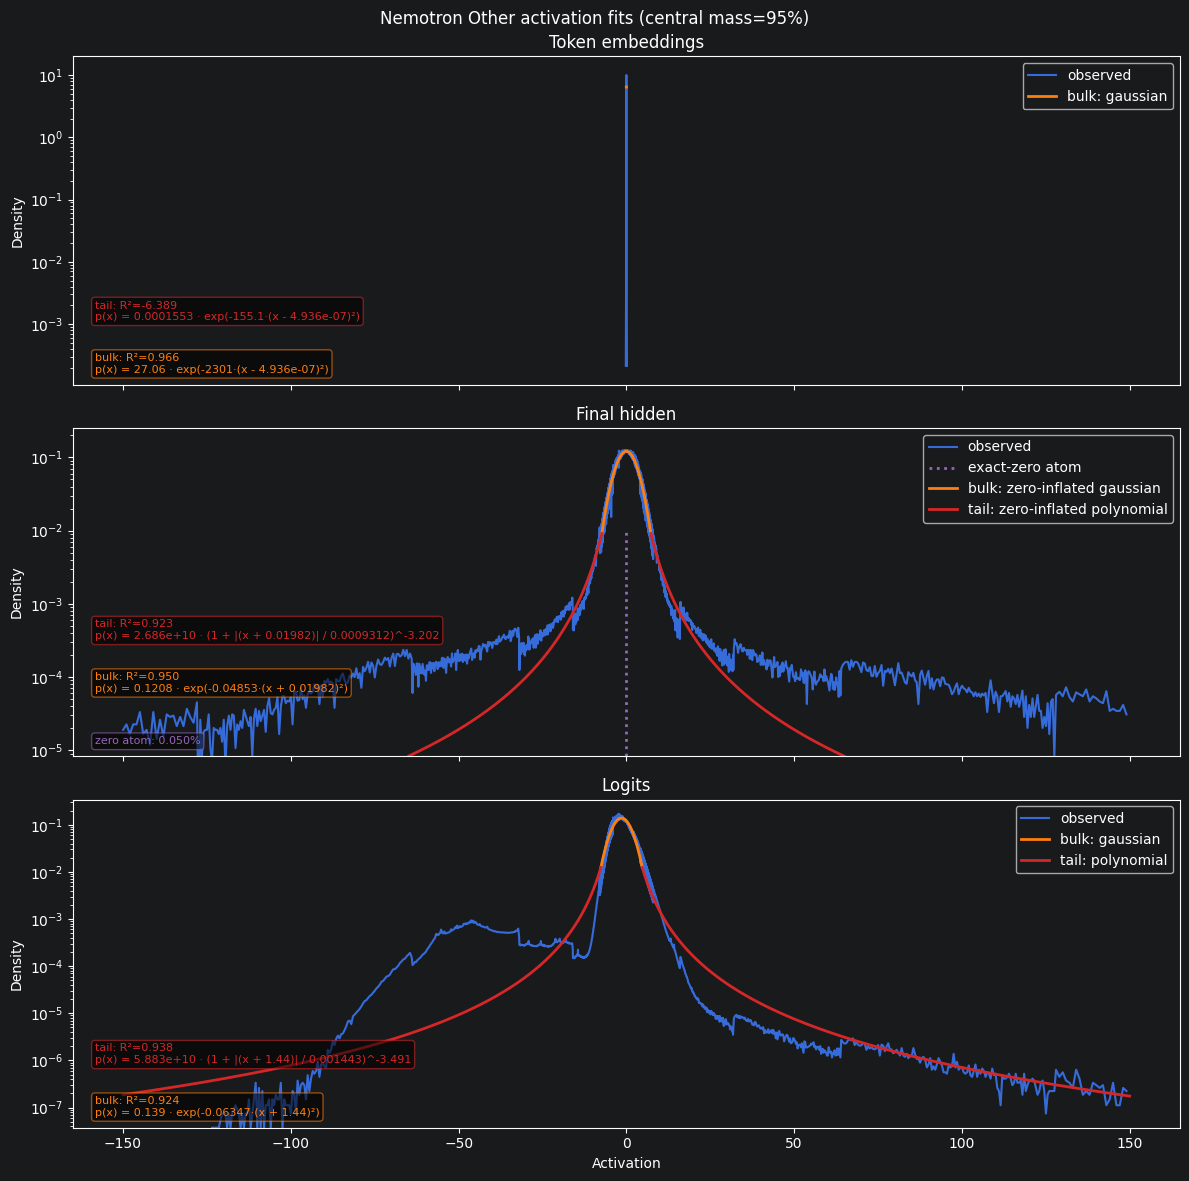

In [5]:
plot_groups = {
    "FFN": [label for label in histograms if label.startswith("FFN ")],
    "Attention": [label for label in histograms if label.startswith("Attention ")],
    "Mamba": [label for label in histograms if label.startswith("Mamba ")],
    "Other": [
        label
        for label in histograms
        if not label.startswith(("FFN ", "Attention ", "Mamba "))
    ],
}

for group, labels in plot_groups.items():
    if not labels:
        continue
    display(Markdown(f"## {group}"))
    plot_histogram_fits(
        {label: histograms[label] for label in labels},
        edges,
        {label: fits[label] for label in labels},
        zero_counts={label: zero_counts[label] for label in labels},
        bulk_mass=bulk_mass,
        title=f"Nemotron {group} activation fits",
        x_label="Activation",
    )